In [ ]:
from google.colab import drive
drive.mount('/gdrive')

data_dir = "/gdrive/MyDrive/VLMs-Dataset"

Mounted at /gdrive


In [ ]:
!pip install huggingface_hub
!huggingface-cli login

/bin/bash: line 1: huggingface-cli: command not found


In [ ]:
!pip install litellm==1.73.6

In [ ]:
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get('Gemma3')

login(hf_token)

# !huggingface-cli login --token {hf_token} # to get the token


In [ ]:
from transformers import AutoProcessor, Gemma3ForConditionalGeneration
from IPython.display import Image as IPImage, display
from PIL import Image
import requests
import torch

# model_id = "google/gemma-3-4b-pt"   pt stands for base model (empty model without output)

model_id = "google/gemma-3-4b-it"

sample_image_pah = f"{data_dir}/0001/page_006.jpg"


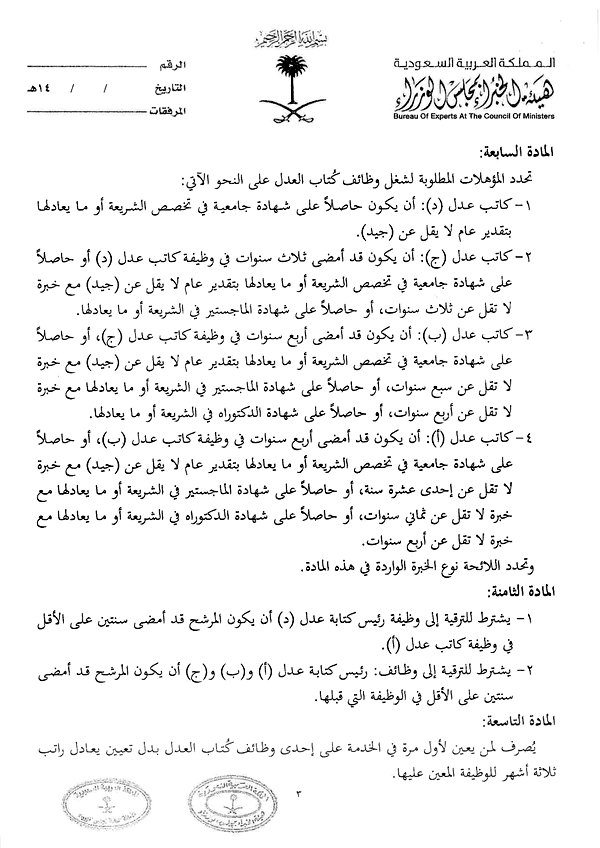

In [ ]:
display(IPImage(filename=sample_image_pah))

In [ ]:
model = Gemma3ForConditionalGeneration.from_pretrained(
    model_id,
    dtype="auto",       # to make the model load in GPU not in Ram
    device_map="auto"   # to make the model load in GPU not in Ram
    ).eval()
processor = AutoProcessor.from_pretrained(model_id) # taking the prompt and the image output them as a template that the model can deal with

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

The image processor of type `Gemma3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [ ]:
prompt = """

# Document Analysis 8 Extraction Prompt

## Task
Extract structured data from document images and return as valid 750N. Use exact enumeration values provided. Extract text in it.

## Output Format

-json
 {
          "document_classification": {
               "type": "enum: official_letter | decree | regulation | statistical_report | table_of_contents | administrative_decision | other",
               "subtype": "string or null",
               "category": "enum: legal | administrative | financial | statistical | correspondence | technical | hr | other",
               "primary_language": "enum: arabic | english | french | mixed | other",
               "secondary_languages": ["array of language codes if multilingual"]
               },

            "source": {
              "issuing_authority": "string: full organization name in ORIGINAL SCRIPT",
              "department": "string or null: specific division/unit in ORIGINAL SCRIPT",
              "location": "string or null: city/region",
              "document_ number": "string or null: official reference number EXACTLY as shown",
              "related_references": ["array: all other document numbers mentioned anywhere in document"],
              "dates": {
                "primary_date":{
                  "date_text": "string: main document date EXACTLY as written",
                  "calendar_type": "enum: hijri | gregorian | unknown",
                  "date_type": "enum: issue_date | effective_date | received_date | other",
                  "indicators": "string: calendar markers like 'هـ' or 'م'",
                  "location_in_document": "enum: header | body | footer | stamp | other"
                },
                "additional_dates": [
                  {
                    "date_text": "string: EXACTLY as written",
                    "calendar_type": "enum: hijri | gregorian | unknown",
                    "date_type": "enum: reference_date | deadline | expiry_date | effective_date | other",
                    "context": "string: brief context of where/why this date appears",
                    "indicators": "string or null"
                  }
                  ]
                  }
                  }
}

## Validation Checklist:
Befor Returning JSOn:
- [ ] All Arabic text kept in arabic (not romanized)
- [ ] Primary document date separated from refrence dates
- [ ] Document number vs file refrence seperated
- [ ] Names and titles in original script
- [ ] All enum values match specified options exactly


## Output InstructionS
Return Only the JSON object. No markdowncode blocks, no explanatory text. start with { and wnd with }



""".strip()
chat_prompt = """
{
"document_classification": {
"type": "enum: official_letter | decree | regulation | statistical_report | table_of_contents | administrative_decision | other",
"subtype": "string or null",
"category": "enum: legal | administrative | financial | statistical | correspondence | technical | hr | other",
"primary_language": "enum: arabic | english | french | mixed | other",
"secondary_languages": ["array of language codes if multilingual"]
},

"source": {
"issuing_authority": "string: full organization name in ORIGINAL SCRIPT",
"department": "string or null",
"location": "string or null",
"document_number": "string or null EXACTLY as shown",
"related_references": ["array of all document numbers mentioned anywhere"],
"page_number": "string or null EXACTLY as shown",
"total_pages": "string or null if mentioned",
"confidentiality_level": "string or null (e.g., سري، عاجل، داخلي)"
},

"dates": {
"primary_date": {
"date_text": "string EXACTLY as written",
"calendar_type": "enum: hijri | gregorian | unknown",
"date_type": "enum: issue_date | effective_date | received_date | other",
"indicators": "string like هـ or م or null",
"location_in_document": "enum: header | body | footer | stamp | margin | other"
},
"additional_dates": [
{
"date_text": "string EXACTLY as written",
"calendar_type": "enum: hijri | gregorian | unknown",
"date_type": "enum: reference_date | deadline | expiry_date | effective_date | other",
"context": "brief explanation of why this date appears",
"indicators": "string or null",
"location_in_document": "enum: header | body | footer | stamp | margin | other"
}
]
},

"people": [
{
"name": "string EXACTLY as written",
"title": "string or null",
"role": "enum: sender | recipient | signatory | mentioned | other",
"signature_present": "boolean"
}
],

"stamps": [
{
"text": "string EXACTLY as visible",
"shape": "string or null (e.g., circular, rectangular)",
"color": "string or null",
"location_in_document": "enum: header | body | footer | margin | other"
}
],

"signatures": [
{
"name": "string or null",
"title": "string or null",
"location_in_document": "enum: header | body | footer | margin | other"
}
],

"content_structure": {
"has_articles": "boolean",
"articles": [
{
"article_number": "string EXACTLY as written",
"article_title": "string or null",
"article_text": "string EXACTLY as written"
}
],
"has_numbered_paragraphs": "boolean",
"numbered_paragraphs": [
{
"number": "string EXACTLY as written",
"text": "string EXACTLY as written"
}
]
},

"full_text": "string: COMPLETE text of the document in reading order exactly as written"
}
""".strip()
### you should complete the prompt

In [ ]:
'''prompt = """
Act Like OCR model, Extract the exact details of the image into a markdown format.
## Output:
```markdown
""".strip()
'''
messages = [
    {
        "role": "system",
        "content": [{"type": "text","text": "you are a helpful assistant"}]
    },

    {
        "role": "user",
        "content": [
            {"type": "image","image": sample_image_pah},
            {"type": "text","text": chat_prompt}, # prompt
                               ]
    }
]

inputs = processor.apply_chat_template(messages,
                                       add_generation_prompt=True, # to create a prompt after fitting
                                       tokenize = True,            # to turn the messages to tokens model can understand
                                       return_dict=True,           # if not provided, one will get only the formatted text, optionally tokenized text.
                                       return_tensors="pt"         # PyTorch
                                       ).to(model.device)          # if the model in gpu this line make the data in gpu so the calulations appened in gpu to

input_len = inputs.input_ids.shape[-1]                             # to get the len of inputes

with torch.inference_mode():
  generation = model.generate(
      **inputs,
      max_new_tokens=1024,
      do_sample=False)
  generation = generation[0][input_len:] # to get the output of the model

output = processor.decode(generation, skip_special_tokens=True)

print(output)


The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Okay, here's an analysis of the document based on your provided schema.

```json
{
"document_classification": {
"type": "official_letter",
"subtype": null,
"category": "legal",
"primary_language": "arabic",
"secondary_languages": []
},

"source": {
"issuing_authority": "الهيئة السعودية للإشراف",
"department": null,
"location": null,
"document_number": "١ / ١٤١١ هـ",
"related_references": [],
"page_number": "1/11",
"total_pages": "11",
"confidentiality_level": null
},

"dates": {
"primary_date": {
"date_text": "١ / ١٤١١ هـ",
"calendar_type": "hijri",
"date_type": "issue_date",
"indicators": "هـ",
"location_in_document": "header"
},
"additional_dates": []
},

"people": [
{
"name": "رئيس كتابة العدل",
"title": "رئيس كتابة العدل",
"role": "signatory",
"signature_present": true
}
],

"stamps": [
{
"text": "الهيئة السعودية للإشراف",
"shape": null,
"color": null,
"location_in_document": "header"
}
],

"signatures": [
{
"name": "رئيس كتابة العدل",
"title": "رئيس كتابة العدل",
"location_in_docu

### Evaluate Gemini3 Model

In [ ]:
from google.colab import userdata
import os
import litellm
from litellm import completion
openrouter_token = userdata.get('openrouter')

In [ ]:
os.environ["OPENAI_API_KEY"] = openrouter_token
os.environ["OPENAI_BASE_URL"] = "https://openrouter.ai/api/v1"

In [ ]:
cloud_model_id = "openai/google/gemini-3.1-flash-lite-preview" # adding openai/ for the scentence to make the llm understand that model is compatable with openai
sample_image_pah = f"{data_dir}/0001/page_006.jpg"


In [ ]:
import base64

def image_to_base64_data_uri(image_path): # convert image to base64 data uri for apis
  with open(image_path, "rb") as f:
    image_base64 = base64.b64encode(f.read()).decode('utf-8')

  # determine image type from extension:
  ext = image_path.lower().split('.')[-1]
  mime_type = f"image/{ext}" if ext == "jpg" else "image/jpeg"

  return f"data:image/{mime_type};base64,{image_base64}"


In [ ]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "text","text": chat_prompt}, # prompt
             {"type": "image_url",
             "image_url":{
                "url":image_to_base64_data_uri(sample_image_pah)
                },
            }
      ]
    }
]

response = completion(
    model=cloud_model_id,
    messages=messages,
    max_tokens=4096,

)


In [ ]:
print(response.choices[0].message.content)

```json
{
  "document_classification": {
    "type": "regulation",
    "subtype": "excerpts from a regulation",
    "category": "legal",
    "primary_language": "arabic",
    "secondary_languages": []
  },
  "source": {
    "issuing_authority": "هيئة الخبراء بمجلس الوزراء",
    "department": null,
    "location": "المملكة العربية السعودية",
    "document_number": null,
    "related_references": [],
    "page_number": "٣",
    "total_pages": null,
    "confidentiality_level": null
  },
  "dates": {
    "primary_date": null,
    "additional_dates": []
  },
  "people": [],
  "stamps": [
    {
      "text": "المملكة العربية السعودية هيئة الخبراء بمجلس الوزراء",
      "shape": "circular",
      "color": null,
      "location_in_document": "footer"
    },
    {
      "text": "المملكة العربية السعودية هيئة الخبراء بمجلس الوزراء",
      "shape": "circular",
      "color": null,
      "location_in_document": "footer"
    }
  ],
  "signatures": [],
  "content_structure": {
    "has_articles": tr

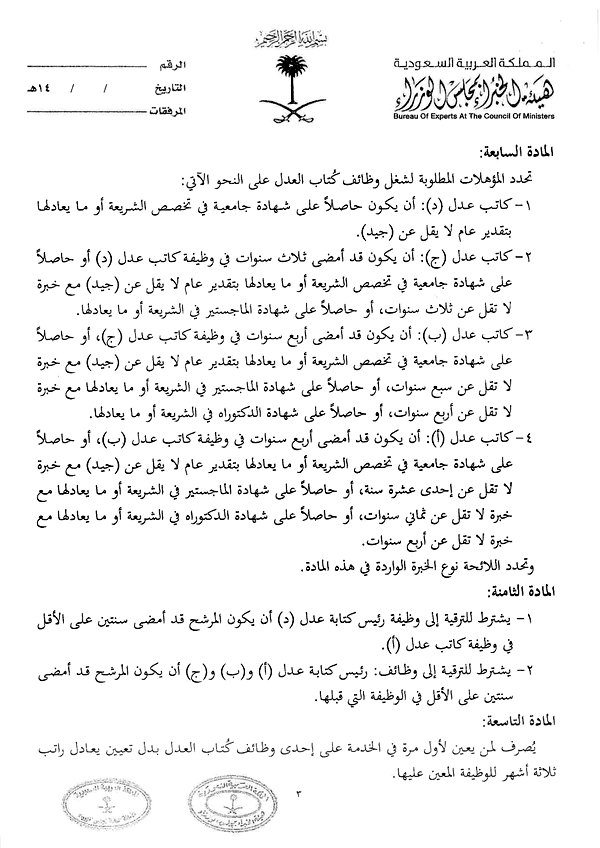

In [ ]:
display(IPImage(filename=sample_image_pah))